In [ ]:
# Standard library imports
import os
import warnings

# Data science and statistics imports
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from kneed import KneeLocator as kl

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# Single-cell analysis imports
import scanpy as sc
import anndata as ad

# Ignore warning messages
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


This notebook evaluates the fidelity of **synthetic single-cell RNA-seq datasets** generated by three generative models — **LVAE**, **scRDiT**, and **scDesign2** — against the real reference data.  
The goal is to assess how well each model reproduces real gene expression patterns across key pancreatic cell types, including *Acinar cells*, *Fibroblasts*, and *Macrophages*.

### Workflow Overview
1. **Data preparation:**  
   Each cell type is subsetted from both real and synthetic datasets, ensuring consistent sampling across models.  
2. **Expression visualization:**  
   Gene-level expression is compared via **boxplots** to visually inspect similarity between real and synthetic distributions.  
3. **Statistical comparison:**  
   Using the `compare_per_group_genes()` function, per-gene metrics such as *Mann–Whitney U test*, *AUC*, and *Cliff’s delta* are computed to quantify differences.  
4. **Global visualization:**  
   The results are summarized through **AUC-centered heatmaps**, which highlight deviations in gene expression between synthetic and real datasets.

### Objective
By integrating both visual and statistical analyses, this notebook provides a comprehensive framework to **benchmark generative models** for single-cell data simulation and to identify which approach best preserves biological realism.


In [ ]:
# Define new function that finds the elbow dimension
def PCA_Elbow_fit(data):
    model = PCA().fit(data)
    explained_variance = model.explained_variance_ratio_
    pcs = list(range(1, explained_variance.shape[0]+1))#enumerate(explained_variance,1)
    klm = kl(pcs, explained_variance, S=1.0, curve='convex', direction='decreasing')
    pcs_used = klm.knee
    pc_list = list(range(1, pcs_used+1))
    new_data = PCA(n_components= pcs_used, svd_solver='arpack').fit_transform(data)

    if pcs_used >50:
        pcs_used=50

    return pcs_used, new_data, pcs, explained_variance, pc_list

In [ ]:
def load_and_merge(folder: str, filetype: str = ".h5ad") -> ad.AnnData:
    """
    Load and merge multiple AnnData (.h5ad) files from a given folder.

    This function scans a directory for all files with the specified extension,
    loads each one as an AnnData object, and concatenates them into a single
    AnnData object.

    Parameters
    ----------
    folder : str
        Path to the folder containing the files to load.
    filetype : str, optional
        File extension to look for (default: '.h5ad').

    Returns
    -------
    AnnData
        A single merged AnnData object containing all loaded datasets.
    """
    adatas = []
    fnames = sorted([f for f in os.listdir(folder) if f.endswith(filetype)])

    for fname in fnames:
        path = os.path.join(folder, fname)
        print(f"Loading: {path}")
        adata = sc.read(path)
        adatas.append(adata)

    adata_merged = ad.concat(adatas, join="outer", fill_value=0)

    return adata_merged


In [ ]:
def _detect_q_col(df):
    """
    Automatically detects the column in a DataFrame that represents a 'q' metric.

    This helper function scans the column names of a pandas DataFrame and looks
    for one that starts with the prefix `'q_'`. This is typically used in
    single-cell or generative model evaluation contexts, where metrics such as
    `'q_LVAE'`, `'q_scRdit'`, or similar are stored in the results table.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame whose columns will be searched for a 'q_' metric column.

    Functionality
    -------------
    1. Converts all column names to lowercase strings.
    2. Filters for those starting with `'q_'`.
    3. If no such columns exist, raises a KeyError with a clear message.
    4. If multiple candidates exist, returns only the first one found.

    Returns
    -------
    str
        The name of the detected 'q_' column.
    """

    cands = [c for c in df.columns if str(c).lower().startswith("q_")]

    if not cands:
        raise KeyError(
            "No 'q' column found (e.g., 'q_LVAE', 'q_scRdit', ...). "
            "Please specify 'q_cols' explicitly."
        )

    return cands[0]

In [ ]:
def heatmap_auc_centered_multi(
    dfs,
    labels=None,
    q_cols=None,
    auc_col="AUC",
    gene_col="gene",
    group_col="group",
    mark="difference",
    q_thresh=0.05,
    delta=0.03,
    align="intersection",
    groups_order=None,
    top_n_genes=None,
    share_scale=True,
    figsize=None,
    outpath=None,
    vmin=-0.15,
    vmax=0.15,
):
    """
    Plots a multi-panel heatmap of centered AUC effects for multiple datasets.

    This function visualizes the differences or similarities in AUC values
    across genes and groups (e.g., cell types) for multiple evaluation panels.
    The heatmap is centered at 0.5 AUC (effect = AUC - 0.5) and optionally marks
    significant differences or similar values with asterisks.

    Parameters
    ----------
    dfs : list of pandas.DataFrame
        List of DataFrames containing results to visualize. Each must include
        columns for genes, groups, AUC values, and optionally q-values.

    labels : list of str, optional
        Titles for each panel. Defaults to "Panel 1", "Panel 2", ...

    q_cols : list of str or None
        Column names for q-values corresponding to each DataFrame. If None,
        automatically detected using `_detect_q_col`.

    auc_col : str
        Column name containing AUC values.

    gene_col : str
        Column name containing gene identifiers.

    group_col : str
        Column name containing group identifiers (e.g., cell types).

    mark : {"difference","similar"}
        Whether to mark genes that are significantly different (q<q_thresh)
        or similar (q≥q_thresh & |effect|≤delta).

    q_thresh : float
        Significance threshold for q-values.

    delta : float
        Threshold for considering an effect similar to 0.

    align : {"intersection","union"}
        Whether to align panels by the intersection of genes/groups or the union.

    groups_order : list of str, optional
        Manual order for columns/groups.

    top_n_genes : int, optional
        If set, display only the top N genes by mean absolute effect across panels.

    share_scale : bool
        Whether to use a common color scale for all panels.

    figsize : tuple, optional
        Figure size (width, height). Auto-calculated if None.

    outpath : str, optional
        Path to save the figure as an image (PNG, PDF, etc.).

    vmin, vmax : float
        Minimum and maximum for the diverging color scale centered at zero.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object.

    axes : list of matplotlib.axes.Axes
        List of axes corresponding to each heatmap panel.
    """

    assert mark in ("difference","similar")
    assert align in ("intersection","union")

    k = len(dfs)
    if labels is None:
        labels = [f"Panel {i+1}" for i in range(k)]
    if q_cols is None:
        q_cols = [None]*k
    assert len(labels)==k and len(q_cols)==k

    pivots, q_marks, all_genes, all_groups = [], [], [], []
    for df, q_col in zip(dfs, q_cols):
        D = df.copy()
        if q_col is None:
            q_col = _detect_q_col(D)
        for col in (auc_col, q_col):
            D[col] = pd.to_numeric(D[col], errors="coerce")
        D["effect"] = D[auc_col] - 0.5

        P = D.pivot_table(index=gene_col, columns=group_col, values="effect", aggfunc="mean")
        pivots.append(P)
        all_genes.append(set(P.index))
        all_groups.append(set(P.columns))

        if mark == "difference":
            M = D[D[q_col] < q_thresh][[gene_col, group_col]]
        else:
            M = D[(D[q_col] >= q_thresh) & (D["effect"].abs() <= delta)][[gene_col, group_col]]
        q_marks.append(M)

    if align == "intersection":
        genes = sorted(set.intersection(*all_genes))
        groups = sorted(set.intersection(*all_groups))
    else:
        genes = sorted(set.union(*all_genes))
        groups = sorted(set.union(*all_groups))

    if groups_order is not None:
        groups = [g for g in groups_order if g in groups] + [g for g in groups if g not in (groups_order or [])]

    if not genes or not groups:
        raise ValueError("No valid intersection/union of genes and/or groups between dataframes.")

    if top_n_genes is not None:
        all_effects = []
        for P in pivots:
            all_effects.append(P.reindex(index=genes, columns=groups).abs())
        mean_abs = np.nanmean([A.values for A in all_effects], axis=0)
        rank = np.nanmean(mean_abs, axis=1)
        order_idx = np.argsort(-rank)[:top_n_genes]
        genes = [genes[i] for i in order_idx]

    mats = [P.reindex(index=genes, columns=groups) for P in pivots]
    if vmin is not None and vmax is not None:
        norms = [TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)] * k
    else:
        if share_scale:
            max_abs = max(np.nanmax(np.abs(M.values)) if M.size else 0.0 for M in mats)
            max_abs = max_abs if np.isfinite(max_abs) and max_abs > 0 else 1e-3
            norms = [TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)] * k
        else:
            norms = []
            for M in mats:
                v = np.nanmax(np.abs(M.values)) if M.size else 1e-3
                v = v if np.isfinite(v) and v > 0 else 1e-3
                norms.append(TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v))

    if figsize is None:
        h = max(2.5, 0.4*len(genes))
        w = max(6, 1.2*len(groups))*k*0.6
        figsize = (w, h)

    fig, axes = plt.subplots(1, k, figsize=figsize, sharey=True)
    if k == 1: axes = [axes]
    ims = []
    for ax, M, lab, norm, marks in zip(axes, mats, labels, norms, q_marks):
        data = M.values.astype(float)
        im = ax.imshow(data, aspect="auto", norm=norm, cmap="RdBu_r")
        ims.append(im)
        ax.set_title(lab)
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yticks(np.arange(len(genes)))
        ax.set_yticklabels(genes)

        g2y = {g:i for i,g in enumerate(genes)}
        c2x = {c:i for i,c in enumerate(groups)}
        for _, r in marks.iterrows():
            g, grp = str(r[gene_col]), str(r[group_col])
            if g in g2y and grp in c2x:
                ax.text(c2x[grp], g2y[g], "*", ha="center", va="center", fontsize=16, color="black")
    axes[0].set_ylabel(" ")

    cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(ims[0] if share_scale else ims[-1], cax=cax, label="AUC − 0.5")
    fig.tight_layout(rect=[0,0,0.9,1])
    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
    return fig, axes

In [9]:
def compare_per_group_genes(
    adata_real, adata_sint,
    genes_por_tipo,
    groupby="cell_type",
    label_modelo="VAE",
    n_cells=None,
    layer=None,
    seed=0,
    add_zero_stats=True,
):
    """
    Compare gene expression between real and synthetic datasets per group.

    This function calculates per-gene statistics for each group (e.g., cell type)
    between a real AnnData object and a synthetic AnnData object. Metrics include
    Mann-Whitney U test, AUC, Cliff's delta, mean, median, and fraction of zeros.

    Parameters
    ----------
    adata_real : AnnData
        Real single-cell dataset.

    adata_sint : AnnData
        Synthetic dataset to compare.

    genes_por_tipo : dict
        Dictionary mapping group names to lists of genes to test.

    groupby : str, optional (default="cell_type")
        Column in `.obs` used to define groups (e.g., cell types).

    label_modelo : str, optional (default="VAE")
        Label for the synthetic dataset, used in column names.

    n_cells : int or None, optional
        Number of cells to sample per group. If None, uses all available cells.

    layer : str or None, optional
        If specified, use this layer in the AnnData objects instead of `.X`.

    seed : int, optional
        Random seed for reproducible subsampling.

    add_zero_stats : bool, optional
        If True, include fraction of zero counts for each gene in the output.

    Returns
    -------
    df : pandas.DataFrame
        DataFrame with per-gene, per-group statistics, including:
        - gene, group
        - n_real, n_synthetic
        - Mann-Whitney U, p-value
        - AUC, Cliff's delta
        - mean and median of real and synthetic
        - fraction of zeros (optional)
    """

    rng = np.random.default_rng(seed)

    def _get_X(a, lyr):
        return a.X if lyr is None else a.layers[lyr]

    def _as_1d(a):
        if hasattr(a, "toarray"):
            a = a.toarray()
        return np.asarray(a).ravel()

    def _sample_idx(n, k):
        if k is None or k >= n:
            return np.arange(n)
        return rng.choice(n, size=k, replace=False)

    if groupby not in adata_real.obs.columns or groupby not in adata_sint.obs.columns:
        raise ValueError(f"'{groupby}' must exist in .obs of both AnnData objects.")

    Xr = _get_X(adata_real, layer)
    Xs = _get_X(adata_sint, layer)

    cats = sorted(set(adata_real.obs[groupby]).intersection(set(adata_sint.obs[groupby])))
    rows = []
    missing = {}

    for cat, genelist in genes_por_tipo.items():
        if cat not in cats:
            continue

        mask_r = (adata_real.obs[groupby].values == cat)
        mask_s = (adata_sint.obs[groupby].values == cat)
        idx_r_all = np.where(mask_r)[0]
        idx_s_all = np.where(mask_s)[0]
        if len(idx_r_all) == 0 or len(idx_s_all) == 0:
            continue

        k = n_cells if n_cells is not None else min(len(idx_r_all), len(idx_s_all))
        idx_r = idx_r_all[_sample_idx(len(idx_r_all), k)]
        idx_s = idx_s_all[_sample_idx(len(idx_s_all), k)]

        gr = set(map(str, adata_real.var_names))
        gs = set(map(str, adata_sint.var_names))
        common = [g for g in genelist if (g in gr and g in gs)]
        missing[cat] = sorted(set(genelist) - set(common))

        for g in common:
            gi_r = adata_real.var_names.get_loc(g)
            gi_s = adata_sint.var_names.get_loc(g)

            xr = _as_1d(Xr[idx_r, gi_r])
            xs = _as_1d(Xs[idx_s, gi_s])
            n1, n2 = len(xr), len(xs)

            if np.all(xr == xr[0]) and np.all(xs == xs[0]) and xr[0] == xs[0]:
                U, p = (n1*n2/2.0, 1.0)
            else:
                U, p = mannwhitneyu(xr, xs, alternative="two-sided", method="auto")

            auc = U / (n1*n2)
            cliffs = 2*auc - 1

            row = {
                "gene": g,
                "group": str(cat),
                "n_real": n1,
                f"n_{label_modelo.lower()}": n2,
                f"U_{label_modelo}": U,
                f"p_{label_modelo}": p,
                "AUC": auc,
                "Cliffs_delta": cliffs,
                "mean_real": float(np.mean(xr)),
                f"mean_{label_modelo.lower()}": float(np.mean(xs)),
                "median_real": float(np.median(xr)),
                f"median_{label_modelo.lower()}": float(np.median(xs)),
            }

            if add_zero_stats:
                row.update({
                    "zero_frac_real": float(np.mean(xr == 0)),
                    f"zero_frac_{label_modelo.lower()}": float(np.mean(xs == 0)),
                })

            rows.append(row)

    df = pd.DataFrame(rows)

    if not df.empty:
        pcol = f"p_{label_modelo}"
        df[f"q_{label_modelo}"] = (
            df.groupby("group")[pcol].transform(lambda p: multipletests(p, method="fdr_bh")[1])
        )

    df.attrs["missing_genes_por_tipo"] = missing
    df.attrs["used_layer"] = layer if layer is not None else "X"
    df.attrs["groupby"] = groupby

    return df


#### **compare_per_group_genes() result**

| gene        | group        | n_real | n_vae | U_VAE   | p_VAE | AUC   | Cliffs_delta | mean_real | mean_vae | median_real | median_vae | zero_frac_real | zero_frac_vae | q_VAE |
| ----------- | ------------ | ------ | ----- | ------- | ----- | ----- | ------------ | --------- | -------- | ----------- | ---------- | -------------- | ------------- | ----- |
| **KRT19**   | Ductal cell  | 150    | 150   | 11225.0 | 0.042 | 0.612 | 0.224        | 0.95      | 0.83     | 0.47        | 0.39       | 0.31           | 0.36          | 0.085 |
| **MUC1**    | Ductal cell  | 150    | 150   | 10540.0 | 0.190 | 0.564 | 0.128        | 1.12      | 1.04     | 0.66        | 0.63       | 0.26           | 0.29          | 0.225 |
| **INS**     | Endocrine    | 120    | 120   | 7000.0  | 0.004 | 0.72  | 0.44         | 3.75      | 2.80     | 2.94        | 2.35       | 0.12           | 0.21          | 0.009 |
| **GCG**     | Endocrine    | 120    | 120   | 7200.0  | 0.002 | 0.73  | 0.46         | 3.45      | 2.60     | 2.81        | 2.20       | 0.09           | 0.18          | 0.006 |
| **S100A10** | Stromal cell | 100    | 100   | 4820.0  | 0.640 | 0.48  | -0.04        | 1.45      | 1.51     | 1.06        | 1.13       | 0.18           | 0.20          | 0.745 |


In [ ]:
def boxplot_gene_expression(
    datasets,
    labels,
    genes=None,
    cell_type=None,
    save_path="figures/"):
    """
    Generates a gene expression boxplot for multiple AnnData datasets,
    randomly subsampling the same number of cells from each dataset.

    Parameters
    ----------
    datasets : list of AnnData
        List of AnnData objects to compare.

    labels : list of str
        Names corresponding to each dataset (used in the plot legend).

    genes : list of str or None
        Genes to include in the plot. If None, the first 10 genes of the first dataset are used.
        If a string and `cell_type` is provided, can use a predefined top gene list.

    cell_type : str or None
        Name of the cell type (used in the plot title and file name).

    save_path : str or None
        Folder path to save the figure. If None, the plot is displayed on screen.
    """

    dfs = []

    # Determine minimum number of cells across datasets
    min_n_cells = min(adata.shape[0] for adata in datasets)

    for adata, label in zip(datasets, labels):
        # Random subsampling
        idx = np.random.choice(adata.shape[0], size=min_n_cells, replace=False)
        sub_adata = adata[idx]

        # Convert AnnData to DataFrame
        df = pd.DataFrame(
            sub_adata.X.toarray() if hasattr(sub_adata.X, 'toarray') else sub_adata.X,
            columns=sub_adata.var_names
        )
        df['Type'] = label
        dfs.append(df)

    # Combine all datasets into one DataFrame
    df_combined = pd.concat(dfs)

    # Select genes to plot
    if genes is None:
        genes = datasets[0].var_names[:10]
    elif isinstance(genes, str) and cell_type:
        genes = top_genes_by_group[cell_type]

    # Convert to long format for seaborn
    df_melted = df_combined.melt(
        id_vars=['Type'],
        value_vars=genes,
        var_name='Gene',
        value_name='Expression'
    )

    # Plot boxplot
    plt.figure(figsize=(20, 6))
    sns.boxplot(
        x='Gene',
        y='Expression',
        hue='Type',
        data=df_melted,
        showfliers=False,
        legend=False
    )

    # Aesthetic adjustments
    plt.xticks(rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel(' ', fontsize=18)
    plt.ylabel('Normalized Expression Level', fontsize=22)
    # Optional title:
    # plt.title(f'Gene expression comparison between samples ({cell_type or "unspecified"})', fontsize=18)

    # Save figure or show
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        filename = f'{cell_type or "generic_expression"}.png'
        save_file = os.path.join(save_path, filename)
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


### ADATA REAL

In [11]:
adata = sc.read_h5ad("path")
adata.obs["cell_origin"] = "real"

### ADATA scdesign2

In [13]:
adata_scdesign2 = sc.read_h5ad("path")
adata_scdesign2.obs["cell_origin"] = "synthetic"

In [14]:
sc.pp.normalize_total(adata_scdesign2, target_sum=1e4)
sc.pp.log1p(adata_scdesign2)

### ADATA scrdit

In [17]:
adata_scrdit = load_and_merge("path")
adata_scrdit.obs["cell_origin"] = "synthetic"

Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/CAF_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/T_CD4_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/T_CD4_reg_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/T_CD8_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/Tumoral_-_Basal-like_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/Tumoral_-_Classical_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/acinar_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/b_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/dendritic_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/ductal_dit_.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/prueba_dit/endocrine_dit_.

### ADATA LVAE

In [22]:
# Normalization of gene expression counts across cells
adata_lvae = load_and_merge("path")
adata_lvae.obs["cell_origin"] = "synthetic"

Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/Acinar cell_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/B cell_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/CAF_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/Dendritic cells_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/Ductal cell_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/Endocrine cells_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/Endothelial cells_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/pruebas_generacion_LVAE_100datos/Fibroblast_syn_gmm.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/

### Process adata

In [ ]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalization of gene expression counts across cells.
adata.layers['counts'] = csr_matrix(adata.X)
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

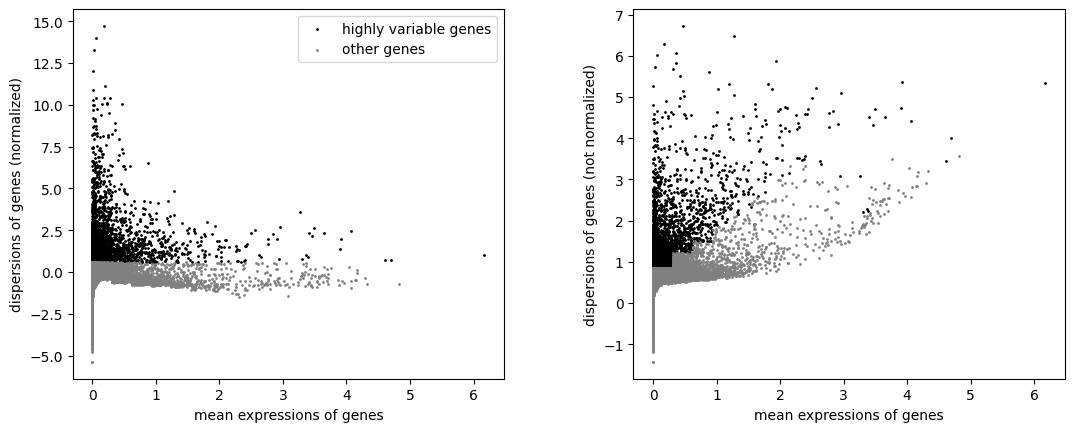

In [20]:
#Record highly variable genes (HVGs)
sc.pp.highly_variable_genes(adata,n_top_genes=3000)
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable].copy()

In [21]:
# Save list of highly variable genes (HVGs)
hvg = list(adata.var_names)

In [23]:
#Reload ADATA REAL
adata = sc.read_h5ad("path")
adata.obs["cell_origin"] = "real"

In [24]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

#HVGs filtering
adata = adata[:, adata.var_names.isin(hvg)].copy()

In [25]:
# Normalization of gene expression counts across cells
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [26]:
#####################################################################################

In [27]:
# Remove the substring "Cholesky" from each cell_type entry
adata_lvae.obs["cell_type"] = adata_lvae.obs["cell_type"].str.replace("Cholesky", "", regex=False)

# (Optional) Remove leading and trailing whitespace after replacement
adata_lvae.obs["cell_type"] = adata_lvae.obs["cell_type"].str.strip()

In [28]:
# Remove the substring "scRDit" from each value in cell_type
adata_scrdit.obs["cell_type"] = adata_scrdit.obs["cell_type"].str.replace("scRDit", "", regex=False)

# (Optional) Remove leading and trailing spaces
adata_scrdit.obs["cell_type"] = adata_scrdit.obs["cell_type"].str.strip()

In [29]:
# Label standardization
adata_scrdit.obs["cell_type"].replace({"Fibroblast cell": "Fibroblast"}, inplace=True)

In [30]:
# Label standardization
adata_scrdit.obs["cell_type"].replace({"Macrophages cell": "Macrophages"}, inplace=True)

In [31]:
#####################################################################################

In [32]:
# Subset each dataset to include only "Acinar cell" observations
real_acinar = adata[adata.obs["cell_type"] == "Acinar cell", :].copy()
lvae_acinar= adata_lvae[adata_lvae.obs["cell_type"] == "Acinar cell", :].copy()
scrdit_acinar = adata_scrdit[adata_scrdit.obs["cell_type"] == "Acinar cell", :].copy()
scdesign2_acinar = adata_scdesign2[adata_scdesign2.obs["cell_type"] == "Acinar cell", :].copy()

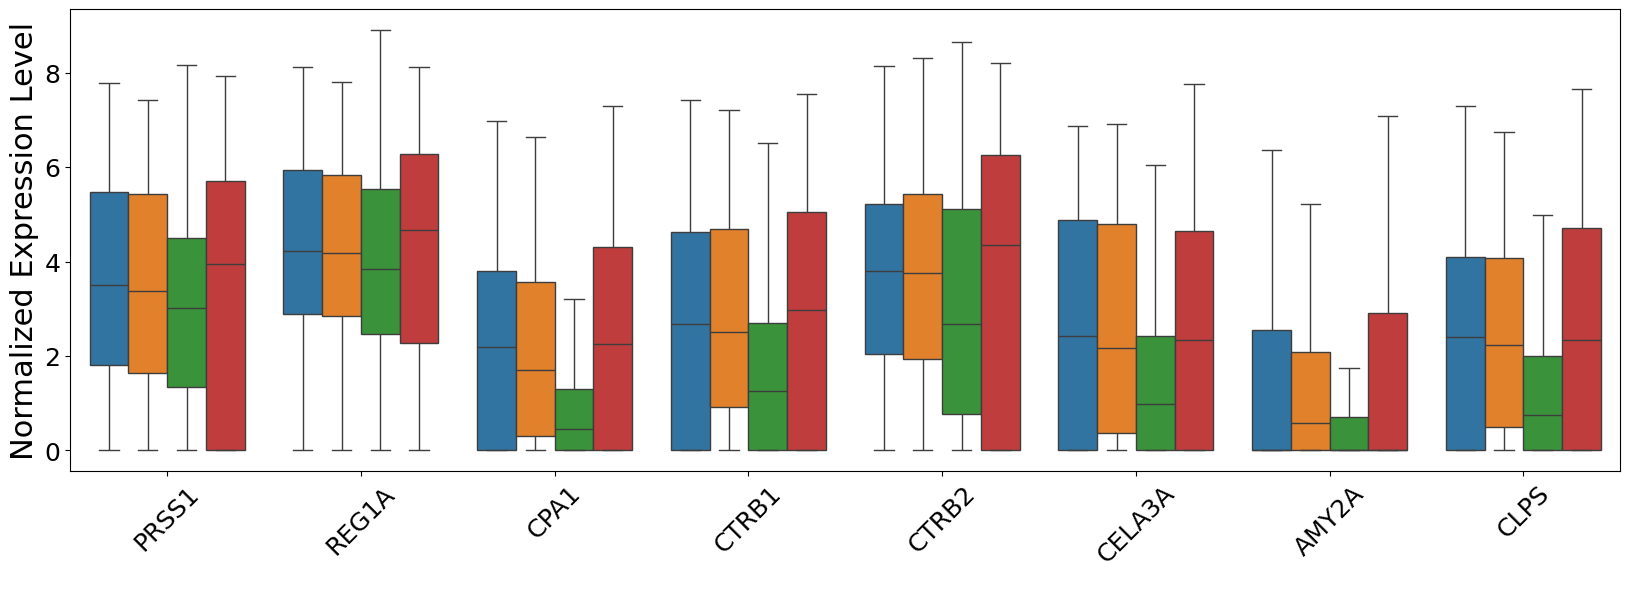

In [53]:
# Compute and save boxplot for Acinar cell gene expression

# This cell compares the expression levels of key acinar marker genes
# across real and synthetic datasets (LVAE, scRDiT, scDesign2).
boxplot_gene_expression(
    [real_acinar, lvae_acinar, scrdit_acinar, scdesign2_acinar],
    ["Real", "LVAE", "scRDiT", "scDesign2"],
    genes=["PRSS1", "REG1A", "CPA1", "CTRB1", "CTRB2", "CELA3A", "AMY2A", "CLPS"],
    cell_type="Acinar cell",
    save_path=None
)


In [35]:
# Compare Acinar cell gene expression between real and synthetic datasets

# For each model (LVAE, scRDiT, scDesign2), perform per-gene statistical comparison
# against the real Acinar cell population using the `compare_per_group_genes` function.
# The analysis computes Mann–Whitney U tests, AUC, Cliff’s delta, and mean/median
# expression differences for key acinar marker genes.

genes_acinar = {
    "Acinar cell": ["PRSS1", "REG1A", "CPA1", "CTRB1", "CTRB2", "CELA3A", "AMY2A", "CLPS"]
}

df_acinar_VAE = compare_per_group_genes(
    adata, adata_lvae,
    genes_por_tipo=genes_acinar,
    groupby="cell_type",
    label_modelo="LVAE",
    n_cells=real_acinar.n_obs,
    layer=None,
    seed=42
)

df_acinar_scrdit = compare_per_group_genes(
    adata, adata_scrdit,
    genes_por_tipo=genes_acinar,
    groupby="cell_type",
    label_modelo="scRDiT",
    n_cells=real_acinar.n_obs,
    layer=None,
    seed=42
)

df_acinar_scdesign2 = compare_per_group_genes(
    adata, scdesign2_acinar,
    genes_por_tipo=genes_acinar,
    groupby="cell_type",
    label_modelo="scDesign2",
    n_cells=real_acinar.n_obs,
    layer=None,
    seed=42
)


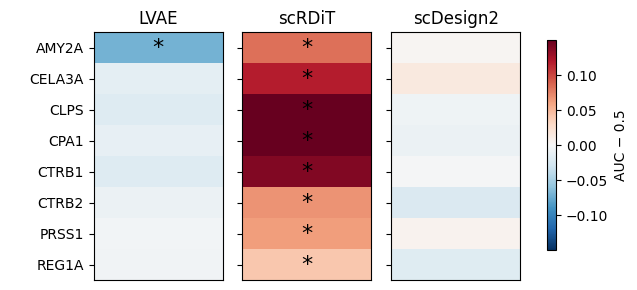

In [ ]:
# Visualize statistical comparison results for Acinar cell genes

# Generate a multi-panel heatmap summarizing AUC-centered effects (AUC − 0.5)
# for each model (LVAE, scRDiT, scDesign2). Each panel represents the
# per-gene effect size distribution within the "Acinar cell" group.
#
# The heatmaps highlight significant differences (q < 0.05) between real and
# synthetic datasets, providing a visual summary of model fidelity at the
# gene level. The color scale is centered at zero (no difference).
#
# Output: figure saved as "acinar_statistical.png" in the working directory.

fig, axes = heatmap_auc_centered_multi(
    [df_acinar_VAE, df_acinar_scrdit, df_acinar_scdesign2],
    labels=["LVAE", "scRDiT", "scDesign2"],
    q_cols=["q_LVAE", "q_scRDiT", "q_scDesign2"],
    mark="difference",
    q_thresh=0.05,
    delta=0.03,
    align="intersection",
    groups_order=None,
    top_n_genes=None,
    share_scale=True,
    figsize=(6, 3),
    outpath="acinar_statistical"
)


In [ ]:
###########################################################################################

In [39]:
# Subset each dataset to include only "Fibroblast" observations
real_fibroblast = adata[adata.obs["cell_type"] == "Fibroblast", :].copy()
lvae_fibroblast = adata_lvae[adata_lvae.obs["cell_type"] == "Fibroblast", :].copy()
scrdit_fibroblast = adata_scrdit[adata_scrdit.obs["cell_type"] == "Fibroblast", :].copy()
scdesign2_fibroblast = adata_scdesign2[adata_scdesign2.obs["cell_type"] == "Fibroblast", :].copy()

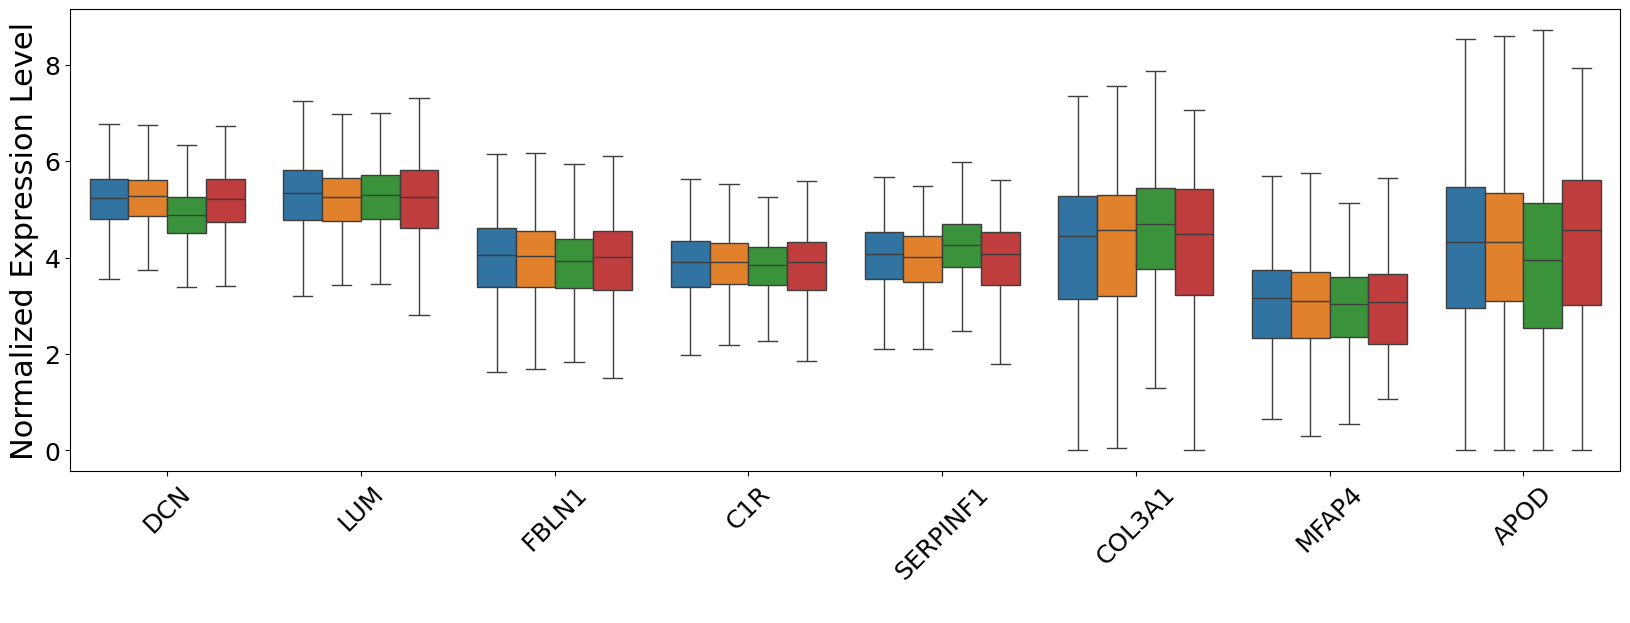

In [45]:
# Compute and save boxplot for Fibroblast gene expression

boxplot_gene_expression(
    [real_fibroblast, lvae_fibroblast, scrdit_fibroblast, scdesign2_fibroblast],
    ["Real", "LVAE", "scRDiT", "scDesign2"],
    genes=["DCN", "LUM", "FBLN1", "C1R", "SERPINF1", "COL3A1", "MFAP4", "APOD"],
    cell_type="Fibroblast",
    save_path= None
)

In [43]:
# Compare Fibroblast gene expression between real and synthetic datasets

genes_fibro = {
    "Fibroblast": ["DCN", "LUM", "FBLN1", "C1R", "SERPINF1", "COL3A1", "MFAP4", "APOD"]
}

df_fibro_VAE = compare_per_group_genes(
    adata, adata_lvae,
    genes_por_tipo=genes_fibro,
    groupby="cell_type",
    label_modelo="LVAE",
    n_cells=real_fibroblast.n_obs,
    layer=None,
    seed=42
)

df_fibro_scrdit = compare_per_group_genes(
    adata, adata_scrdit,
    genes_por_tipo=genes_fibro,
    groupby="cell_type",
    label_modelo="scRDiT",
    n_cells=real_fibroblast.n_obs,
    layer=None,
    seed=42
)

df_fibro_scdesign2 = compare_per_group_genes(
    adata, adata_scdesign2,
    genes_por_tipo=genes_fibro,
    groupby="cell_type",
    label_modelo="scDesign2",
    n_cells=real_fibroblast.n_obs,
    layer=None,
    seed=42
)

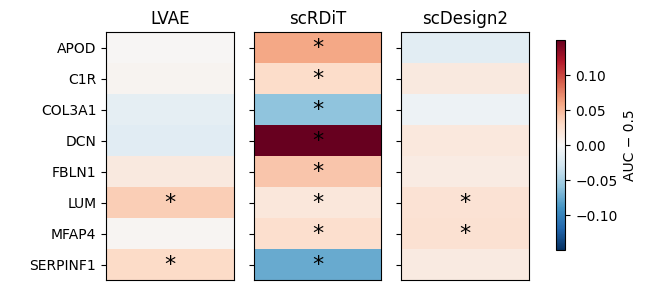

In [ ]:
# Visualize statistical comparison results for Fibroblast genes

fig, axes = heatmap_auc_centered_multi(
    [df_fibro_VAE, df_fibro_scrdit, df_fibro_scdesign2],
    labels=["LVAE", "scRDiT", "scDesign2"],
    q_cols=["q_LVAE", "q_scRDiT", "q_scDesign2"],
    mark="difference",
    q_thresh=0.049,
    delta=0.03,
    align="intersection",
    groups_order=None,
    top_n_genes=None,
    share_scale=True,
    figsize=(6.1, 3),
    outpath="fibroblast_statistical"
)

In [ ]:
##############################################################################################

In [46]:
# Subset each dataset to include only "Macrophages" observations

real_macrophages = adata[adata.obs["cell_type"] == "Macrophages", :].copy()
lvae_macrophages = adata_lvae[adata_lvae.obs["cell_type"] == "Macrophages", :].copy()
scrdit_macrophages = adata_scrdit[adata_scrdit.obs["cell_type"] == "Macrophages", :].copy()
scdesign2_macrophages = adata_scdesign2[adata_scdesign2.obs["cell_type"] == "Macrophages", :].copy()

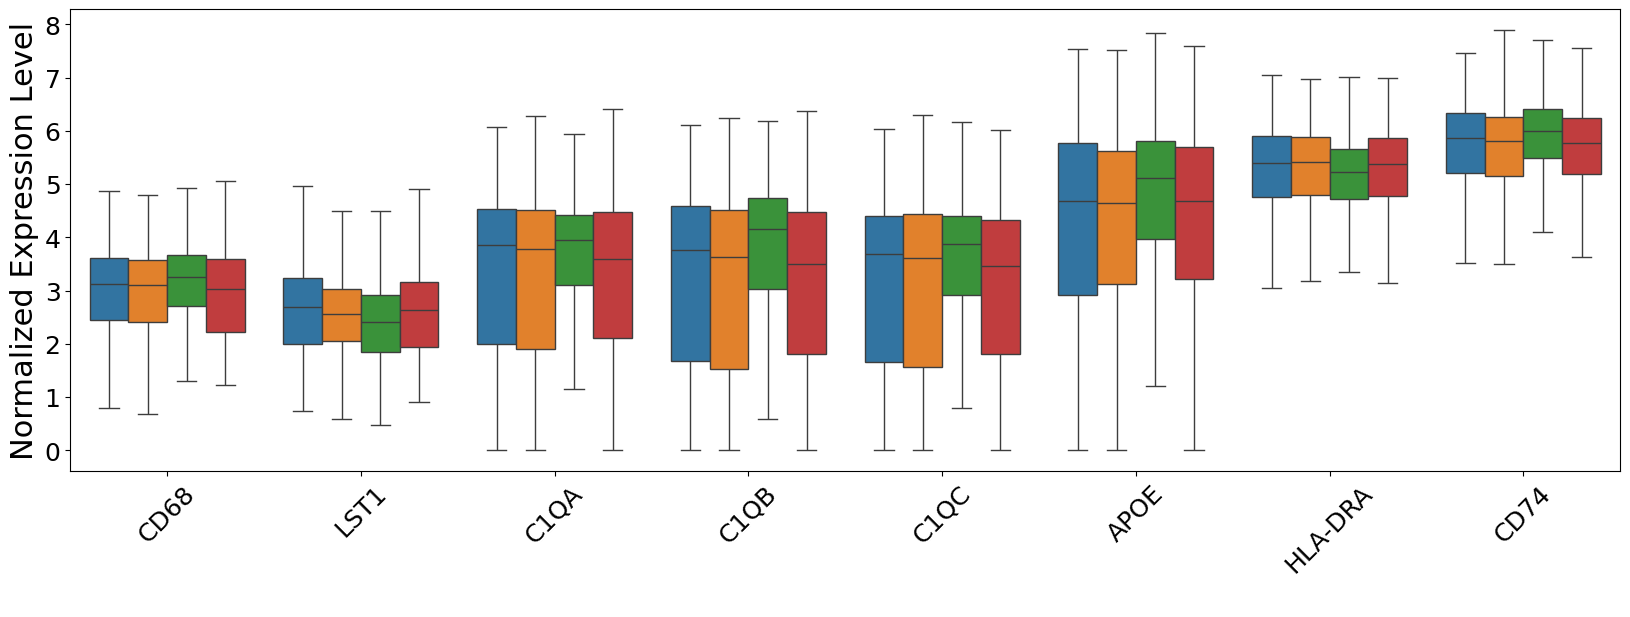

In [49]:
# Compute and save boxplot for Macrophages gene expression

boxplot_gene_expression(
    [real_macrophages, lvae_macrophages, scrdit_macrophages, scdesign2_macrophages],
    ["Real", "LVAE", "scRDiT", "scDesign2"],
    genes=["CD68", "LST1", "C1QA", "C1QB", "C1QC", "APOE", "HLA-DRA", "CD74"],
    cell_type="Macrophages",
    save_path=None
)

In [50]:
# Compare Macrophages gene expression between real and synthetic datasets

genes_macro = {
    "Macrophages": ["CD68", "LST1", "C1QA", "C1QB", "C1QC", "APOE", "HLA-DRA", "CD74"]
}

df_macro_VAE = compare_per_group_genes(
    adata, adata_lvae,
    genes_por_tipo=genes_macro,
    groupby="cell_type",
    label_modelo="LVAE",
    n_cells=real_macrophages.n_obs,
    layer=None,
    seed=42
)

df_macro_scrdit = compare_per_group_genes(
    adata, adata_scrdit,
    genes_por_tipo=genes_macro,
    groupby="cell_type",
    label_modelo="scRDiT",
    n_cells=real_macrophages.n_obs,
    layer=None,
    seed=42
)

df_macro_scdesign2 = compare_per_group_genes(
    adata, adata_scdesign2,
    genes_por_tipo=genes_macro,
    groupby="cell_type",
    label_modelo="scDesign2",
    n_cells=real_macrophages.n_obs,
    layer=None,
    seed=42
)

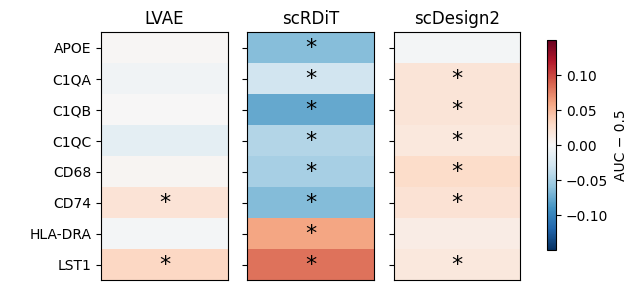

In [ ]:
# Visualize statistical comparison results for Macrophages genes

fig, axes = heatmap_auc_centered_multi(
    [df_macro_VAE, df_macro_scrdit, df_macro_scdesign2],
    labels=["LVAE", "scRDiT", "scDesign2"],
    q_cols=["q_LVAE", "q_scRDiT", "q_scDesign2"],
    mark="difference",
    q_thresh=0.05,
    delta=0.03,
    align="intersection",
    groups_order=None,
    top_n_genes=None,
    share_scale=True,
    figsize=(6, 3),
    outpath="macro_statistical"
)


In [52]:
###########################################################################################################